In [1]:
import pandas as pd

df = pd.read_csv("../../datasets/MX_with_labels.csv")
df.head()

,spotify_id,name,artists,daily_rank,daily_movement,weekly_movement,country,snapshot_date,popularity,is_explicit,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,average_song
0,5Z75FvRFiultmPFWHx5jQ7,7 Dias,"Gabito Ballesteros, Tito Double P",1,0,1,MX,2025-02-17,85,True,...,-3.749,1,0.0614,0.3860,0.000000,0.0839,0.577,111.913,3,Higher
1,78HEzDEs1QUnHB2DbxgC1s,Te Quería Ver,"Alemán, Neton Vega",2,1,1,MX,2025-02-17,82,False,...,-5.182,0,0.0681,0.1880,0.000017,0.0922,0.448,100.019,4,About_Average
2,0LTwdL5yZ6YOTEGUQPFuSN,ROSONES,Tito Double P,3,1,1,MX,2025-02-17,88,True,...,-5.939,1,0.0318,0.7040,0.000010,0.1170,0.604,120.129,3,Lower
3,7sd6zMrgGpEa7NkQm9TRrg,NADIE,Tito Double P,4,1,2,MX,2025-02-17,87,True,...,-4.710,1,0.1140,0.4650,0.000000,0.1200,0.526,92.604,4,About_Average
4,4eLDmhsJW3JoZTXCAozHor,Loco,Neton Vega,5,-3,45,MX,2025-02-17,61,False,...,-5.502,1,0.0686,0.0741,0.007680,0.1390,0.636,91.981,4,Lower


In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["spotify_id", "name", "artists", "snapshot_date", "country", "album_name", "album_release_date", "popularity", "daily_movement", "weekly_movement", "daily_rank"], axis=1, inplace=False)
y = df["popularity"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

estimator = RandomForestRegressor(n_estimators=100, min_samples_split=2, min_samples_leaf=1, max_features='log2', max_depth=None)
encode = OneHotEncoder()
scaler = MinMaxScaler()


preprocessing = make_column_transformer((encode, ['average_song']), (scaler, [
       'is_explicit', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'] ), remainder='passthrough')

pipeline = make_pipeline(preprocessing, estimator)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(),
                                                  ['average_song']),
                                                 ('minmaxscaler',
                                                  MinMaxScaler(),
                                                  ['is_explicit', 'duration_ms',
                                                   'danceability', 'energy',
                                                   'key', 'loudness', 'mode',
                                                   'speechiness',
                                                   'acousticness',
                                                   'instrumentalness',
                                                   'liveness', 'valence',
                                                   'tempo',
                                                   'time_signature'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_features='log2'))])

In [12]:
import shap as shap

fraction_of_data = 1

feature_names = preprocessing.get_feature_names_out()

X_train_transformed = preprocessing.transform(X_train.sample(frac=fraction_of_data))

explainer = shap.Explainer(
    estimator.predict,
    X_train_transformed,
    feature_names=feature_names
)

# TreeExplainer took 2.5 hours with 0.001 fraction
# Explainer took 

small = X_test.sample(frac=fraction_of_data)
X_test_transformed = preprocessing.transform(small)
shap_values = explainer(X_test_transformed)
    
    

PermutationExplainer explainer: 4763it [15:45,  4.98it/s]                          


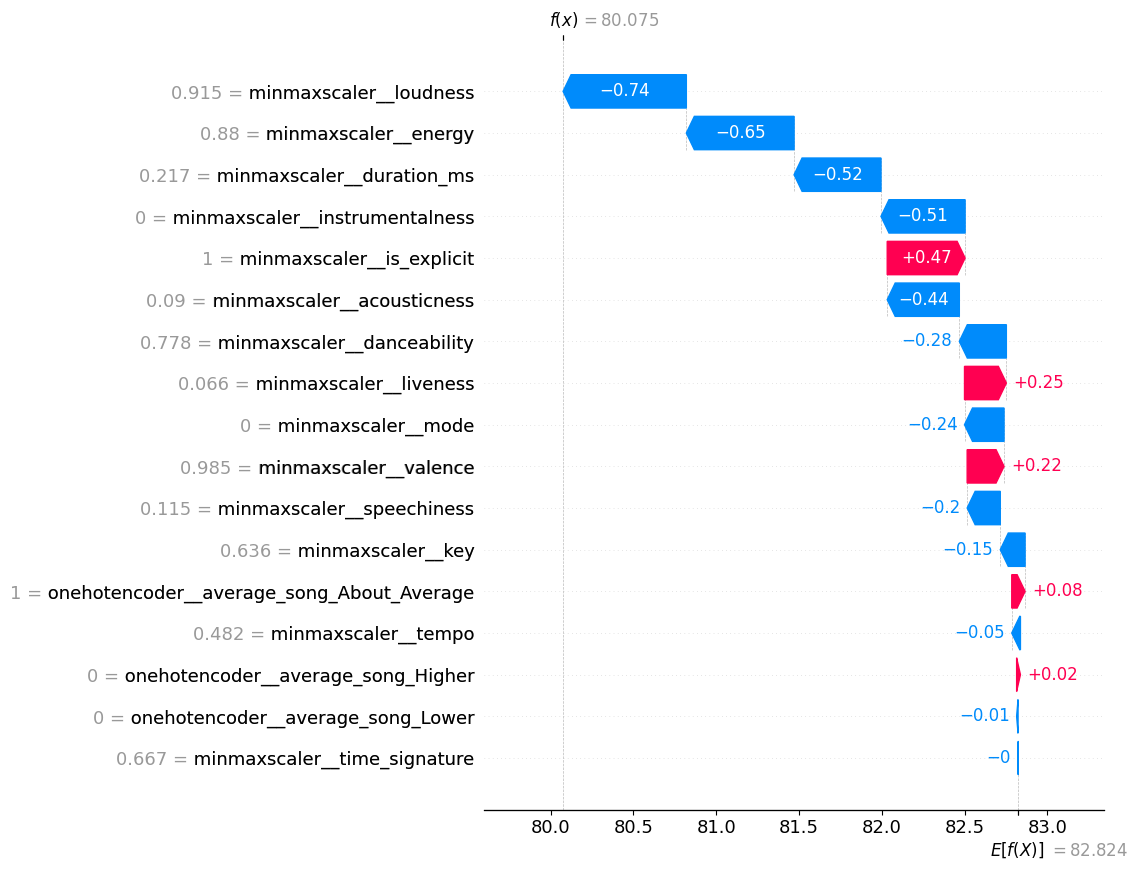

In [13]:
# PLots a single prediction and how it got there
shap.plots.waterfall(shap_values[0], max_display=50)


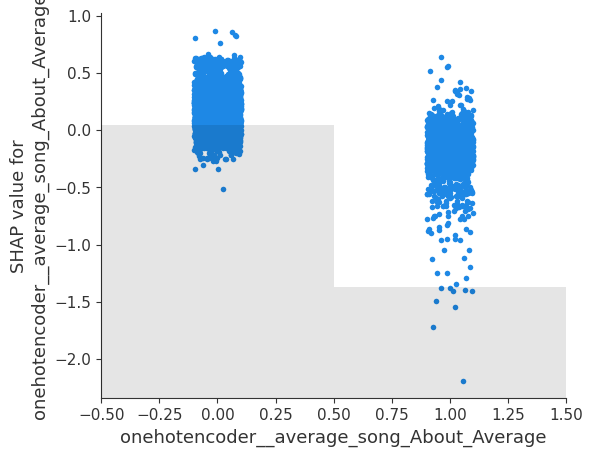

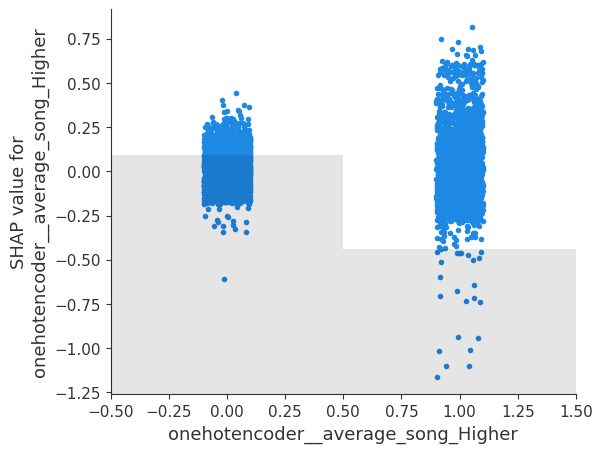

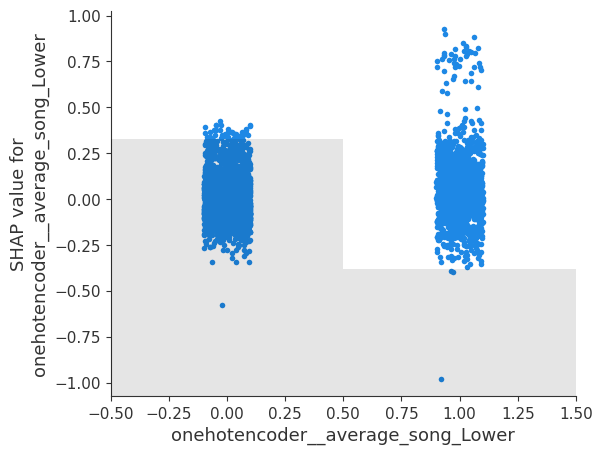

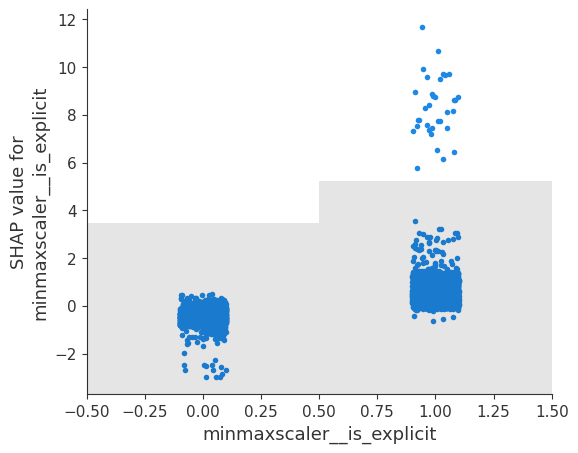

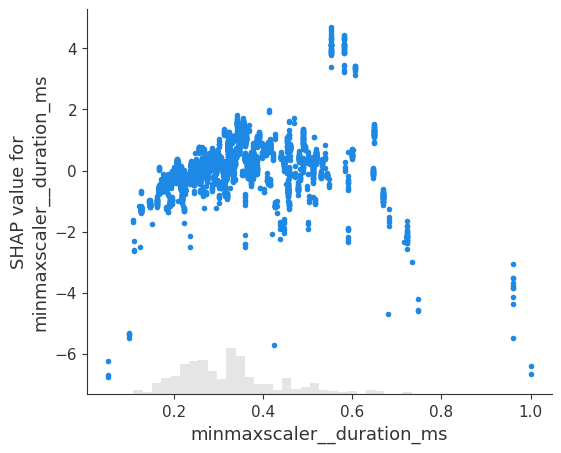

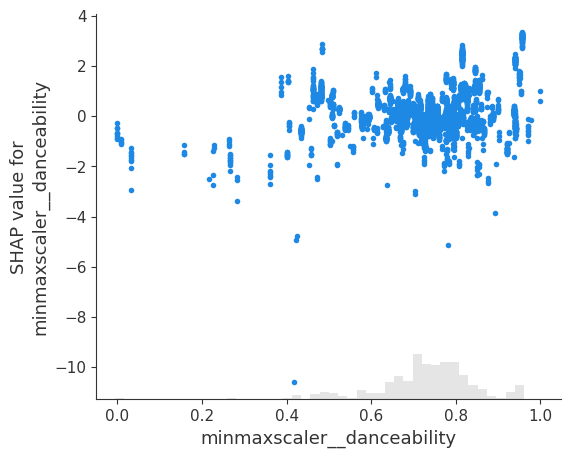

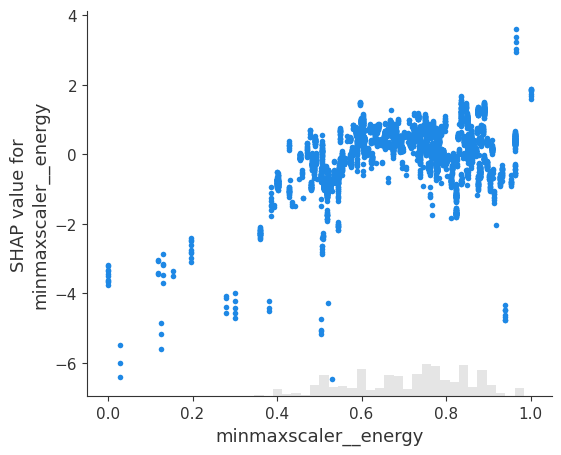

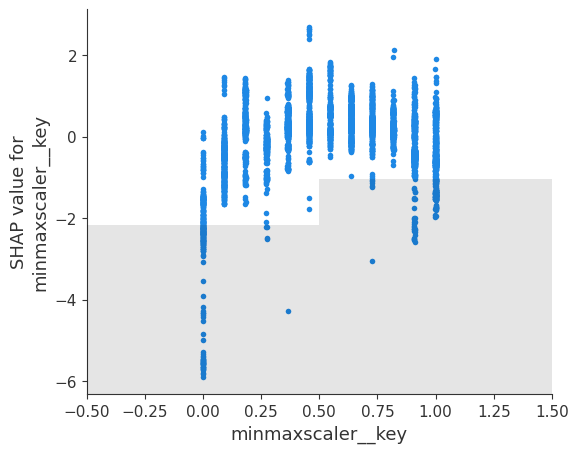

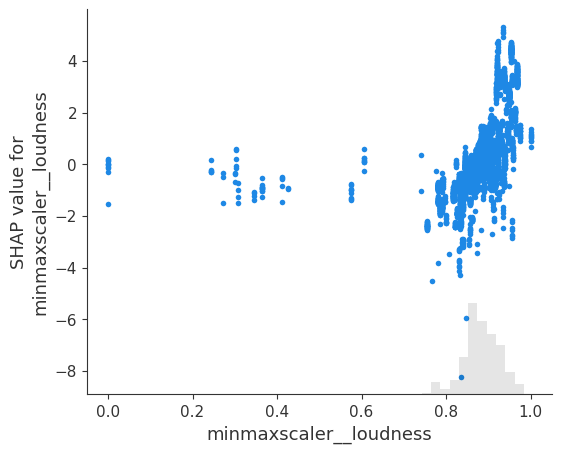

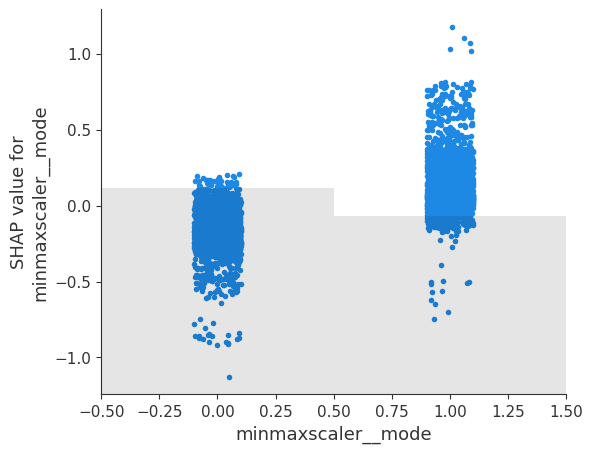

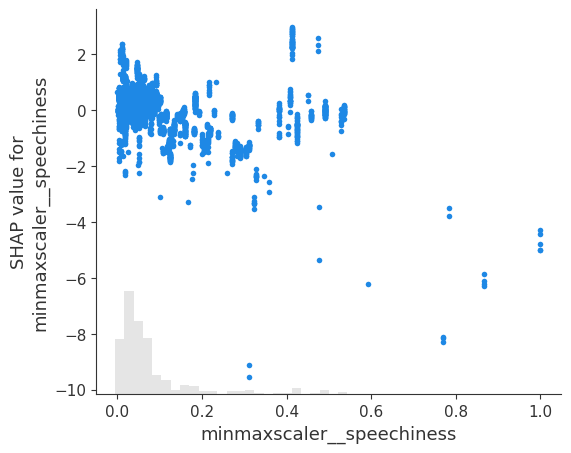

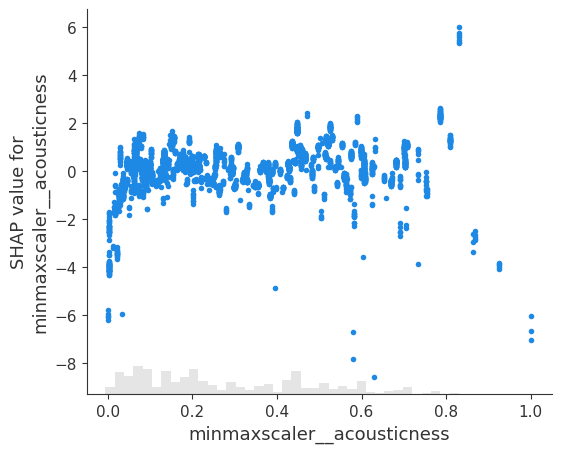

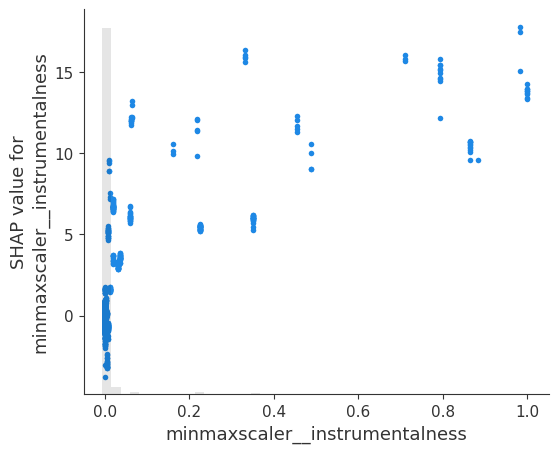

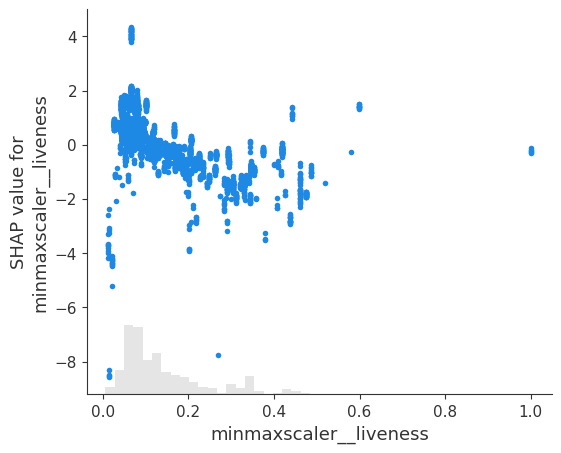

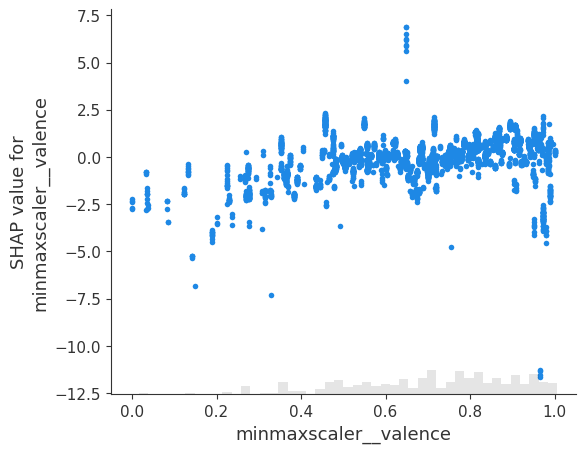

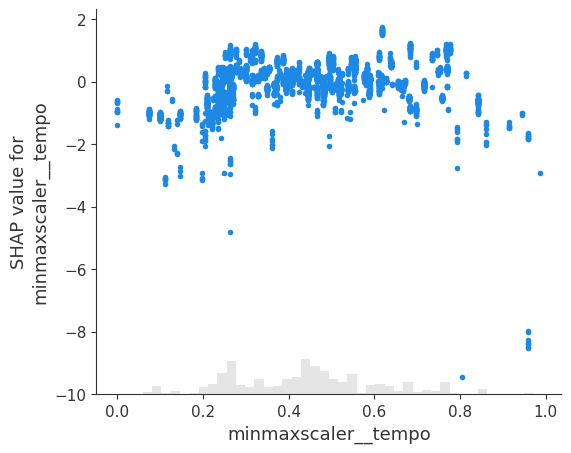

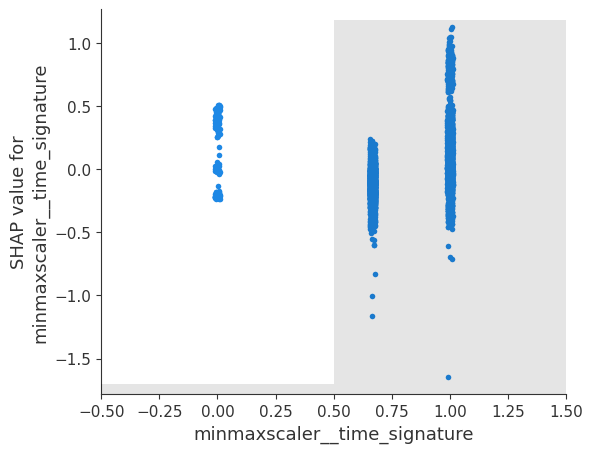

In [14]:
# Plots how each feature affects the model's output
for i in range(len(feature_names)):
    shap.plots.scatter(shap_values[:, i])

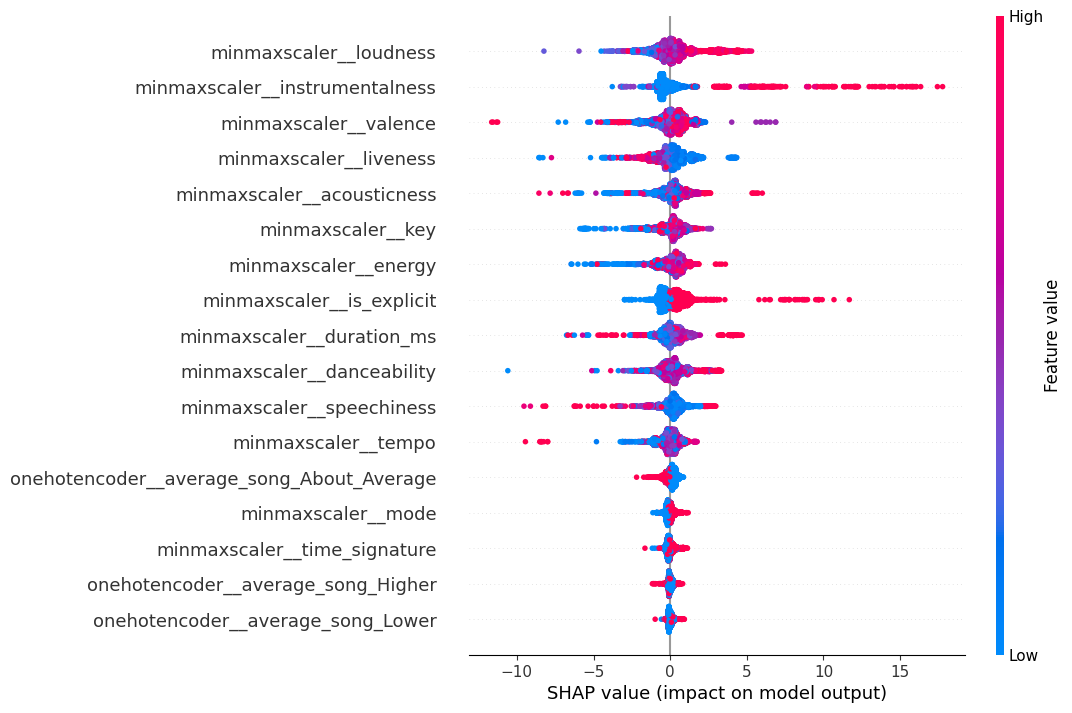

In [15]:
# Plots the summary of the model's predictions
shap.plots.beeswarm(shap_values, max_display=50)

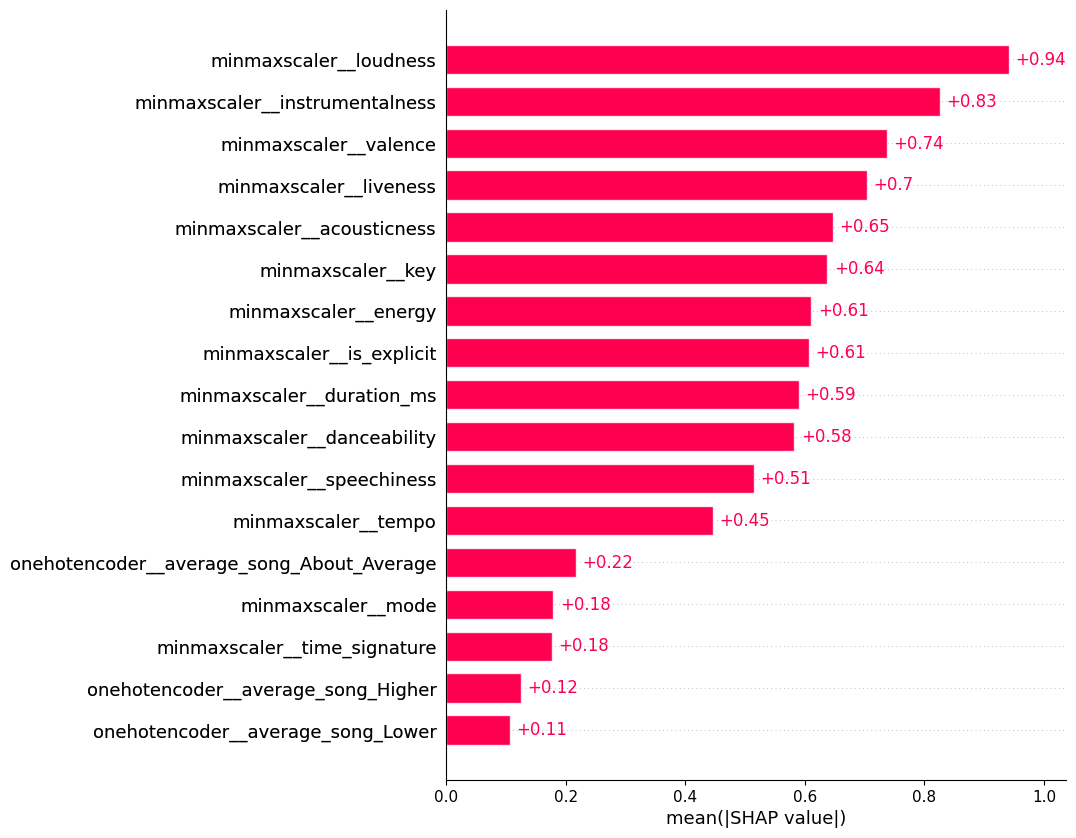

In [16]:
# Bar chart of features that most affect the model's output
shap.plots.bar(shap_values, max_display=50)